In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from numba import njit
from os.path import exists
from os import makedirs
import pandas as pd
import networkx as nx

cmap=plt.get_cmap("viridis")


## Functions

In [3]:
#Assignment 1
def edges_panda_to_G(df):
    G = nx.from_pandas_edgelist(df,source="node_1",target="node_2",create_using=nx.Graph())
    return G

def G_to_DV(G):

    #change of saving structure: vector and pointer
    D=np.array(list(dict(G.degree()).values()))
    N=np.size(D)
    #print("N=",N)

    V_list=[]
    for i in G.nodes:
        neighbours=G.adj[i].keys()
        for n in neighbours:
            V_list.append(n)

    V=np.array(V_list,dtype=int)

    return D,V
#Assignment 2

def pdf(G):
    k_hist = nx.degree_histogram(G)
    k_values = np.arange(len(k_hist))

    Pk = np.array(k_hist) / np.sum(k_hist)
    
    return Pk,k_values

def complementary_cdf(G):

    k_hist = nx.degree_histogram(G)
    k_values = np.arange(len(k_hist))

    Pk = np.array(k_hist) / np.sum(k_hist)
    ccPk=np.zeros_like(Pk)
    for i in range(np.size(Pk)):
        ccPk[i]=1-np.sum(Pk[:i+1])

    return ccPk,k_values

def average_nnd(G,D,V):

    N=np.size(D)

    k_hist = nx.degree_histogram(G)
    k_values = np.arange(len(k_hist))

    Pk = np.array(k_hist) / np.sum(k_hist)

    knn=np.zeros_like(Pk)

    for i in range(D.size):
        ki=D[i]
        start=np.sum(D[:i])
        end=start+ki
        for j in V[start:end]:
            knn[ki]+=D[j]/(Pk[ki]*N*ki)

    #normalizations
    k_mean=np.sum(Pk*k_values)
    k2_mean=np.sum(Pk*k_values**2)

    kappa=k2_mean/k_mean

    return knn/kappa,k_values

def clustering_coefficient(G,D):
    
    #triangles in each node
    triangles = nx.triangles(G)
    T=np.array(list(triangles.values()))
    n_pairs=D*(D-1)/2
    ci=np.zeros_like(T, dtype=float)
    mask=n_pairs>0
    ci[mask]=T[mask]/n_pairs[mask]

    C=np.zeros_like(Pk)

    for i in range(D.size):
        ki=D[i]
        C[ki]+=ci[i]/(Pk[ki]*N)

    return C,k_values

#Plots

def individual_plot(x,y,xlabel,ylabel,name):
    plt.figure()
    plt.plot(x, y, linestyle="none",marker="o",color=cmap(0),markersize=3)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(xlabel,fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.savefig(name,bbox_inches="tight")
    plt.show()

def comparison_plot(x,y1,y2,xlabel,ylabel,name):
    plt.figure()
    plt.plot(x, y1, linestyle="none",marker="o",color=cmap(0),markersize=3, label="Original network")
    plt.errorbar(x,y2[:,0],xerr=None,yerr=y2[:,1],linestyle="none",marker="o",color="Red",label="CM rewiring",markersize=3)
    plt.legend(loc='upper center',bbox_to_anchor=(0.5, +1.2),fancybox=True,\
            shadow=True,ncol=4,fontsize=18)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(xlabel,fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.savefig(name,bbox_inches="tight")
    plt.show()


## Assignment 1

In [4]:

#reading the data file containing the edge list (non-repeated)
file_name="../gb_ptn/edges_rail.dat"
df = pd.read_csv(file_name, sep=r"\s+",header=None,names=["node_1", "node_2"])
df

,node_1,node_2
0,9100CHRISTC,9100HINTONA
1,9100CHRISTC,9100POKSDWN
2,9100CHRISTC,9100NMILTON
3,9100LNSD,9100CCRT
4,9100LNSD,9100PLKSHWE
...,...,...
4445,9100CKHL,9100DUMBRCK
4446,9100EGHAM,9100ASCOT
4447,9100BRGHTN,9100HASOCKS
4448,9100MERSTHM,9100REDHILL


In [5]:

#creating the graph
G=edges_panda_to_G(df)

#is the graph connected? No
print("Connected?",nx.is_connected(G))

#How many different cconnected components do we have?
print("Number of connected components:",nx.number_connected_components(G))

#We have 2 different connected components: sizes?
print("Which sizes?")
for c in nx.connected_components(G):
    print(len(c))

#We will only work with the bigger connected component and ignore the other (2573 vs 2 nodes)
largest_cc = max(nx.connected_components(G), key=len)
Gcc = G.subgraph(largest_cc).copy()

#It is conneceted? Yes
print("Largest connected component is connected?",nx.is_connected(Gcc))

Connected? False
Number of connected components: 2
Which sizes?
2573
2
Largest connected component is connected? True


In [7]:
#number of nodes
N=Gcc.number_of_nodes()
print("N=",N)

#number of edges
E=Gcc.number_of_edges()
print("E=",E)

#mean degree
k_mean=2*E/N
print("<k>=",k_mean)



N= 2573
E= 4449
<k>= 3.458219976680917


In [23]:
#Let's translate the codes to numbers
mapping = {node: i for i, node in enumerate(Gcc.nodes())}

G_f = nx.relabel_nodes(Gcc, mapping)

#we create the vectors D and V, and check that the paramaters are the same
D,V=G_to_DV(G_f)

N=D.size
print("N=",N)


E=V.size//2
print("E=",E)

k_mean=2*E/N
print("<k>=",k_mean)

#node's degree
print("Node's degree")
print("Node","      ","Degree")
i=0
for k in D:
    print("",i,"         ",k)
    i+=1


N= 2573
E= 4449
<k>= 3.458219976680917
Node's degree
Node        Degree
 0           3
 1           2
 2           2
 3           5
 4           3
 5           3
 6           2
 7           3
 8           2
 9           2
 10           2
 11           3
 12           3
 13           2
 14           2
 15           3
 16           2
 17           7
 18           5
 19           7
 20           16
 21           7
 22           2
 23           5
 24           15
 25           6
 26           3
 27           5
 28           15
 29           2
 30           12
 31           21
 32           2
 33           6
 34           4
 35           16
 36           6
 37           5
 38           20
 39           4
 40           2
 41           2
 42           2
 43           8
 44           8
 45           5
 46           7
 47           3
 48           3
 49           12
 50           10
 51           8
 52           2
 53           1
 54           12
 55           4
 56           8
 57           2


## Assignment 2

In [ ]:
#saving the plots:
from os.path import exists
from os import makedirs

directory_save="../images/"
if not exists(directory_save):
    makedirs(directory_save)

In [ ]:

#PDF of node's degree
Pk,k_values=pdf(G_f)

#Complementary cumulative probability distribution
ccPk,k_values=complementary_cdf(G_f)

#average nearest neighbour degree - assortevely correlations
knn,k_values=average_nnd(G_f,D,V)

#average clustering coefficient 
C,k_values=clustering_coefficient(G_f,D)


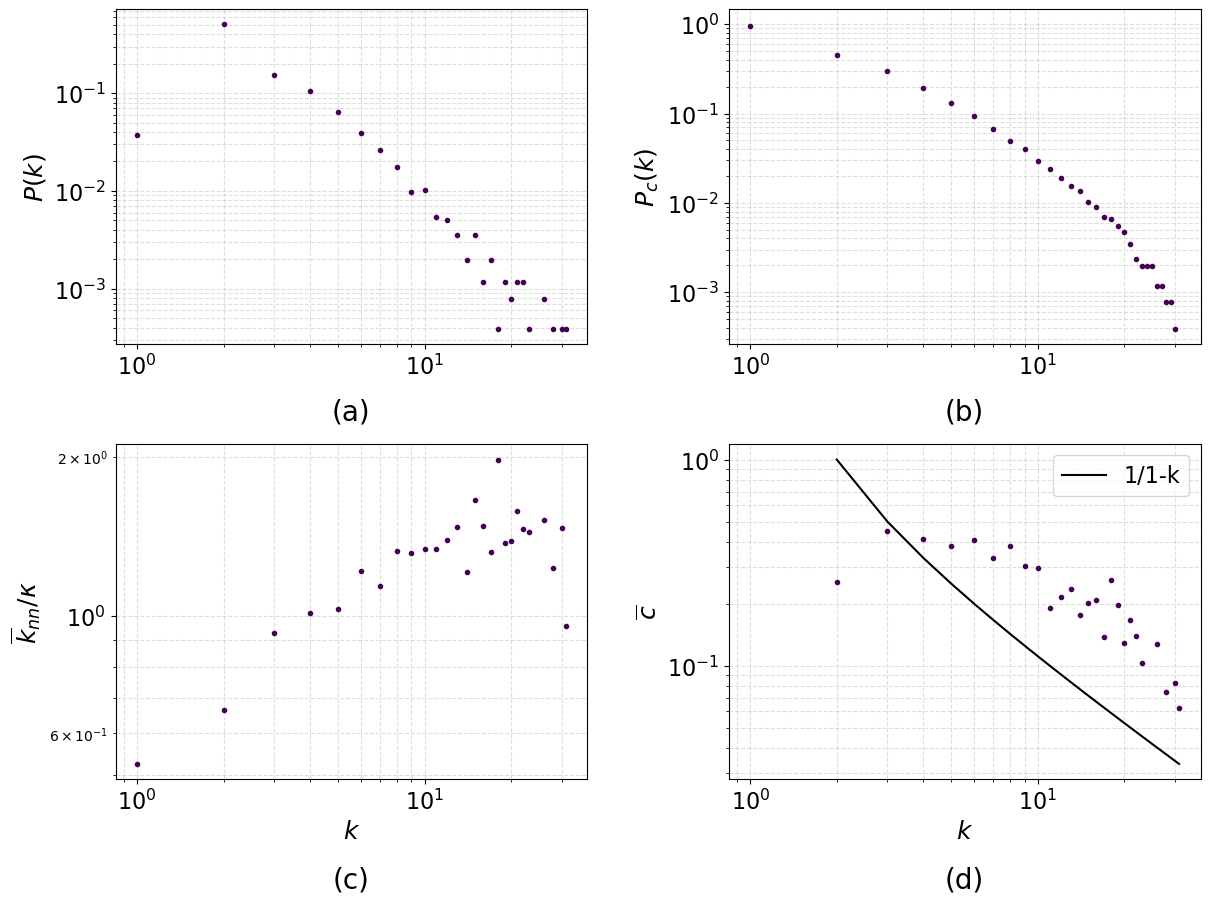

In [ ]:

titles=["(a)","(b)","(c)","(d)"]
results_list=[Pk,ccPk,knn,C]
y_label=["$P(k)$","$P_c(k)$",r"$\overline{k}_{nn}/\kappa$",r"$\overline{c}$"]
x=k_values

fig, ax = plt.subplots(2, 2, figsize=(14,10))
fig.subplots_adjust(wspace=0.3,hspace=0.3)
count=0
for i in range(2):
    for j in range(2):
        if j==1 and i==1:
            ax[i][j].plot(k_values[2:],1/(k_values[2:]-1),color="black")
            ax[i][j].legend(["1/1-k"],fontsize=16)

        title_j=titles[count]
        y=results_list[count]
        ax[i][j].plot(x,y,linestyle="none",marker="o",markersize=3,c=cmap(0))
        ax[i][j].set_xscale("log")
        ax[i][j].set_yscale("log")
        ax[i][j].tick_params(axis='both', labelsize=16)
        ax[i][j].grid(True, which="both", linestyle="--", alpha=0.4)
        ax[i][j].set_ylabel(y_label[count],fontsize=18)
        
        

        if i==1:
            ax[i][j].set_xlabel("$k$",fontsize=18)
            ax[i][j].set_title(title_j,y=-0.35, fontsize=20)
        else:
            ax[i][j].set_title(title_j,y=-0.25, fontsize=20)
            
        count+=1



name="Assignment_2"
plt.savefig(directory_save+name+".pdf",bbox_inches="tight")
plt.show()

c:\Users\ASUS\anaconda3\Lib\site-packages\powerlaw\distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


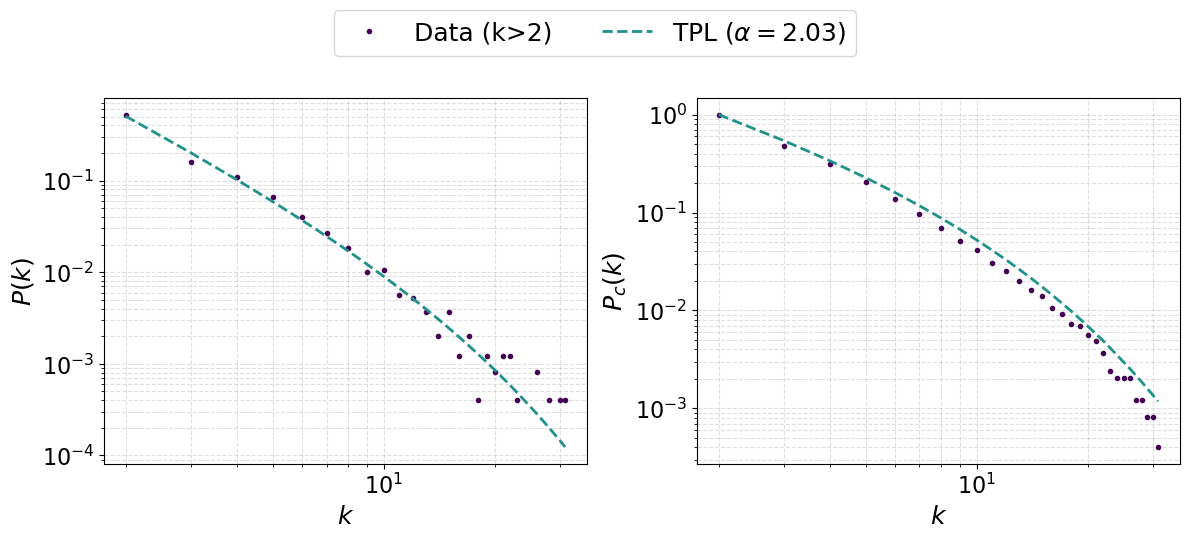

xmin   = 2.0
alpha  = 2.0328220093513245
Lambda = 0.09451393220781956
D      = 0.06815822004164207


In [ ]:
import powerlaw
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# Empirical PDF
# ===========================
Pk, k_values = pdf(G_f)

# Degrees
degrees = np.array([d for _, d in G_f.degree() if d > 0])

# Fit
fit = powerlaw.Fit(degrees, discrete=True, verbose=False)
tpl = fit.truncated_power_law

xmin = tpl.xmin

# ===========================
# Restrict to the fitted tail
# ===========================
mask = k_values >= xmin
k_values_2 = k_values[mask]
Pk_2 = Pk[mask]

# Renormalize PDF on the tail
Pk_2 = Pk_2 / Pk_2.sum()

# Empirical CCDF on the tail
ccPk_2 = np.cumsum(Pk_2[::-1])[::-1]

# ===========================
# Plot
# ===========================
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ---------- PDF ----------
ax[0].plot(
    k_values_2,
    Pk_2,
    linestyle="none",
    marker="o",
    markersize=3,
    color=cmap(0),
    label="Data (k>2)"
)

tpl.plot_pdf(
    ax=ax[0],
    color=cmap(1/2),
    linestyle="--",
    linewidth=2,
    label=rf"TPL ($\alpha={tpl.alpha:.2f}$)"
)

ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("$k$", fontsize=18)
ax[0].set_ylabel(r"$P(k)$", fontsize=18)
ax[0].tick_params(axis="both", labelsize=16)
ax[0].grid(True, which="both", linestyle="--", alpha=0.4)

# ---------- CCDF ----------
ax[1].plot(
    k_values_2,
    ccPk_2,
    linestyle="none",
    marker="o",
    markersize=3,
    color=cmap(0),
    label="Data (k>2)"
)

tpl.plot_ccdf(
    ax=ax[1],
    color=cmap(1/2),
    linestyle="--",
    linewidth=2,
    label=rf"TPL ($\alpha={tpl.alpha:.2f}$)"
)

ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("$k$", fontsize=18)
ax[1].set_ylabel(r"$P_c(k)$", fontsize=18)
ax[1].tick_params(axis="both", labelsize=16)
ax[1].grid(True, which="both", linestyle="--", alpha=0.4)

# ===========================
# Single legend
# ===========================
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, .95),
    ncol=2,
    fontsize=18,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig("../images/TPL.pdf",bbox_inches="tight")

plt.show()




print(f"xmin   = {tpl.xmin}")
print(f"alpha  = {tpl.alpha}")
print(f"Lambda = {tpl.Lambda}")
print(f"D      = {tpl.D}")

## Assignment 3

In [ ]:
communities=np.zeros((100))
for seed_i in range(100):
    communities [seed_i] = len(nx.community.louvain_communities(Gcc,seed=seed_i))

print("# communities:",np.mean(communities),"+-",1.96*np.std(communities)/100)

# of communities: 39


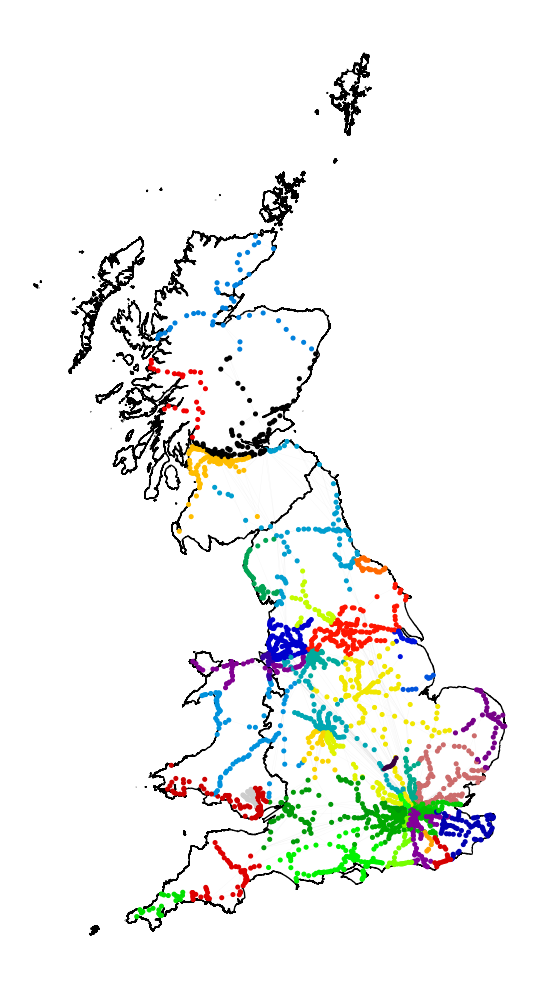

In [ ]:
# =========================
# COMMUNITIES
# =========================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

# =========================
# 1. NODOS (ESTACIONES)
# =========================

stations = pd.read_csv(
    "../gb_ptn/co_Rail.dat",
    sep=r"\s+",
    header=None,
    names=["code", "E", "N"]
)

# quedarse solo con nodos del grafo
stations = stations[
    stations["code"].isin(Gcc.nodes())
]

gdf_nodes = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(
        stations.E,
        stations.N
    ),
    crs="EPSG:27700"
)

# diccionario código -> coordenadas
coords = {
    row["code"]: (
        row.geometry.x,
        row.geometry.y
    )
    for _, row in gdf_nodes.iterrows()
}

# =========================
# 2. COMMUNITIES
# =========================

communities = nx.community.louvain_communities(
    Gcc,
    seed=5
)

print("# of communities:", len(communities))

# nodo -> comunidad
partition = {
    node: i
    for i, comm in enumerate(communities)
    for node in comm
}

# color de cada nodo
node_colors = [
    partition[code]
    for code in gdf_nodes["code"]
]

# =========================
# 3. CONTORNO UK
# =========================

uk = gpd.read_file("country_region.shp")

uk = uk.to_crs("EPSG:27700")

# =========================
# 4. PLOT
# =========================

fig, ax = plt.subplots(
    figsize=(8, 10)
)

# --- contorno UK ---
uk.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1
)

# =========================
# 5. LINKS
# =========================

for s, t in Gcc.edges():

    if s in coords and t in coords:

        x1, y1 = coords[s]
        x2, y2 = coords[t]

        ax.plot(
            [x1, x2],
            [y1, y2],
            color="gray",
            alpha=0.08,
            linewidth=0.25,
            zorder=1
        )

# =========================
# 6. NODOS
# =========================

scatter = ax.scatter(
    gdf_nodes.geometry.x,
    gdf_nodes.geometry.y,
    c=node_colors,
    cmap="nipy_spectral",
    s=7,
    zorder=2
)

# =========================
# 7. ESTILO FINAL
# =========================

ax.set_aspect("equal")

ax.set_axis_off()


plt.tight_layout()
plt.savefig("../images/communities_map.pdf",bbox_inches="tight")

plt.show()

## Assignment 4

In [ ]:
#statistics function
@njit
def statistics(x):
    """Returns mean and its standard deviation of a 2D array (N, N_i),
    computed over simulations (axis=1)."""
    
    #mean and standard deviation
    sumx=np.sum(x,axis=1)
    sumx2=np.sum(x**2,axis=1)
    N=x.shape[1]
    xmed=sumx/N
    x2med=sumx2/N
    s2=(N*(x2med-xmed**2))/(N-1)
    s=s2**0.5
    
    #standard deviation of the mean (CLT)
    var=s2/N
    var[var<0]=0
    sigma=(var)**0.5
    unc=1.96*sigma
    return xmed,unc


In [ ]:
#list of degrees: D
pdf_array=np.zeros((len(k_values),100),dtype="float64")
c_cdf_array=np.zeros_like(pdf_array)
annd_array=np.zeros_like(pdf_array)
cc_array=np.zeros_like(pdf_array)
communities_array=np.zeros((100))

for i in range(100):
    G_rand = G_f.copy()
    nx.double_edge_swap(
        G_rand,
        nswap=10*E,
        max_tries=100*E,
        seed=i
    )
    D,V=G_to_DV(G_rand)
    pdf_array[:,i]=pdf(G_rand)[0]
    c_cdf_array[:,i]=complementary_cdf(G_rand)[0]
    annd_array[:,i]=average_nnd(G_rand,D,V)[0]
    cc_array[:,i]=clustering_coefficient(G_rand,D)[0]
    communities_array[i]=len(nx.community.louvain_communities(G_rand,seed=5))
    

#average results
pdf_results=np.zeros((len(k_values),2))
pdf_results[:,0],pdf_results[:,1]=statistics(pdf_array)

c_cdf_results=np.zeros((len(k_values),2))
c_cdf_results[:,0],c_cdf_results[:,1]=statistics(c_cdf_array)

annd_results=np.zeros((len(k_values),2))
annd_results[:,0],annd_results[:,1]=statistics(annd_array)

cc_results=np.zeros((len(k_values),2))
cc_results[:,0],cc_results[:,1]=statistics(cc_array)

print("# communities:",np.mean(communities_array),"+-",1.96*np.std(communities_array)/100)

# communities: 30.86 +- 0.03268208169624451


# of communities: 30


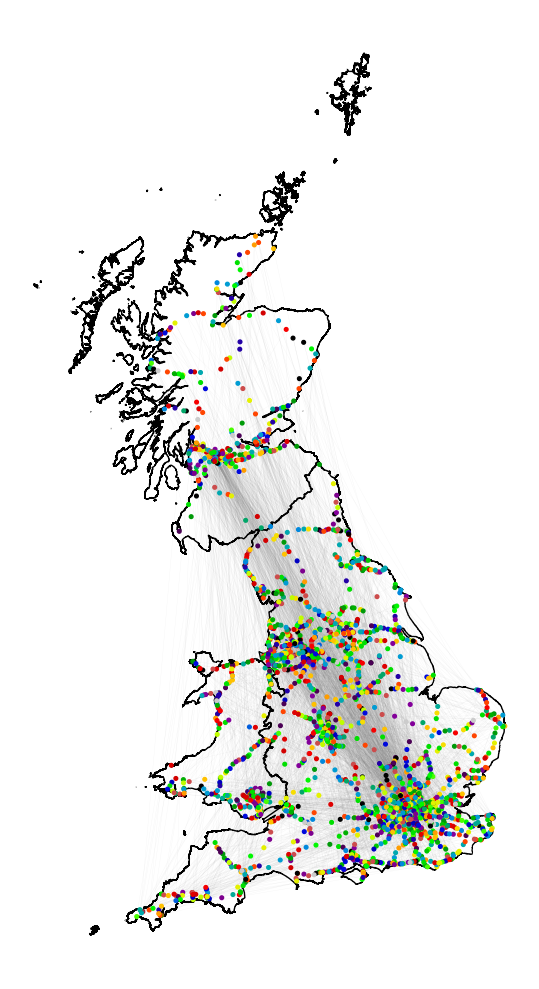

In [ ]:
# =========================
# COMMUNITIES
# =========================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

# =========================
# 1. NODOS (ESTACIONES)
# =========================

stations = pd.read_csv(
    "../gb_ptn/co_Rail.dat",
    sep=r"\s+",
    header=None,
    names=["code", "E", "N"]
)

# quedarse solo con nodos del grafo
stations = stations[
    stations["code"].isin(Gcc.nodes())
]

gdf_nodes = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(
        stations.E,
        stations.N
    ),
    crs="EPSG:27700"
)

# diccionario código -> coordenadas
coords = {
    row["code"]: (
        row.geometry.x,
        row.geometry.y
    )
    for _, row in gdf_nodes.iterrows()
}

# =========================
# 2. COMMUNITIES
# =========================
G_rand=Gcc.copy()

nx.double_edge_swap(
        G_rand,
        nswap=10*E,
        max_tries=100*E,
        seed=5
    )

communities = nx.community.louvain_communities(
    G_rand,
    seed=5
)

print("# of communities:", len(communities))

# nodo -> comunidad
partition = {
    node: i
    for i, comm in enumerate(communities)
    for node in comm
}

# color de cada nodo
node_colors = [
    partition[code]
    for code in gdf_nodes["code"]
]

# =========================
# 3. CONTORNO UK
# =========================

uk = gpd.read_file("country_region.shp")

uk = uk.to_crs("EPSG:27700")

# =========================
# 4. PLOT
# =========================

fig, ax = plt.subplots(
    figsize=(8, 10)
)

# --- contorno UK ---
uk.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1
)

# =========================
# 5. LINKS
# =========================

for s, t in G_rand.edges():

    if s in coords and t in coords:

        x1, y1 = coords[s]
        x2, y2 = coords[t]

        ax.plot(
            [x1, x2],
            [y1, y2],
            color="gray",
            alpha=0.08,
            linewidth=0.25,
            zorder=1
        )

# =========================
# 6. NODOS
# =========================

scatter = ax.scatter(
    gdf_nodes.geometry.x,
    gdf_nodes.geometry.y,
    c=node_colors,
    cmap="nipy_spectral",
    s=7,
    zorder=2
)

# =========================
# 7. ESTILO FINAL
# =========================

ax.set_aspect("equal")

ax.set_axis_off()


plt.tight_layout()
plt.savefig("../images/communities_map_rewired.pdf",bbox_inches="tight")

plt.show()

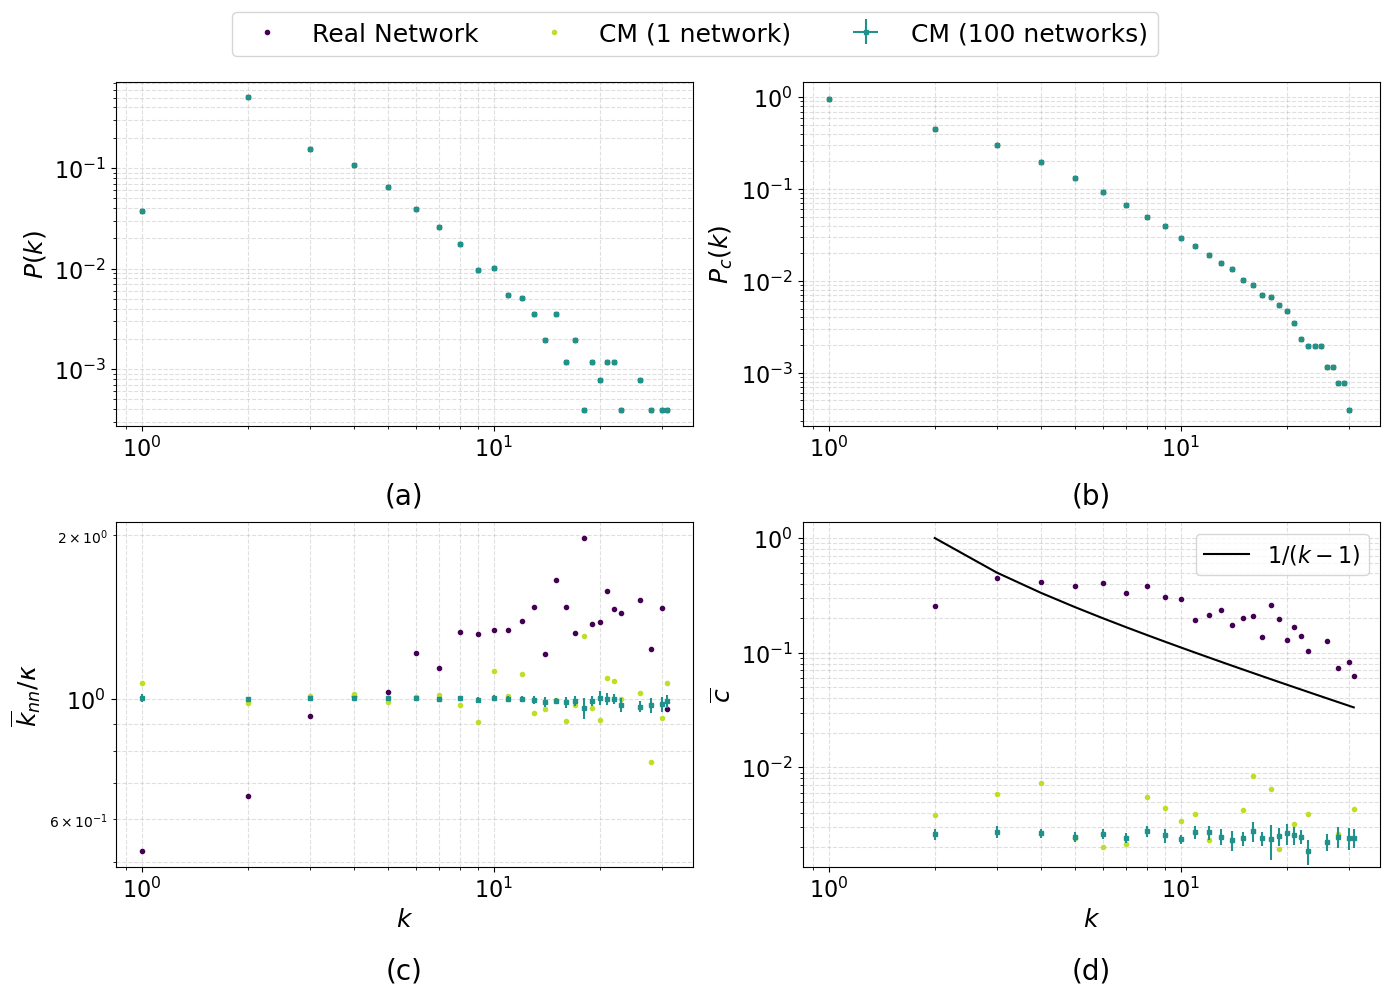

In [ ]:
#individual simulation
G_rand = G_f.copy()
nx.double_edge_swap(
    G_rand,
    nswap=10*E,
    max_tries=100*E,
    seed=5
)
D,V=G_to_DV(G_rand)
pdf_results_i=pdf(G_rand)[0]
c_cdf_results_i=complementary_cdf(G_rand)[0]
annd_results_i=average_nnd(G_rand,D,V)[0]
cc_results_i=clustering_coefficient(G_rand,D)[0]

#plot

titles = ["(a)", "(b)", "(c)", "(d)"]

results_list = [Pk, ccPk, knn, C]
results_list_2 = [pdf_results_i,c_cdf_results_i,annd_results_i,cc_results_i]
results_list_3 = [pdf_results,c_cdf_results,annd_results,cc_results]

y_label = ["$P(k)$", "$P_c(k)$", r"$\overline{k}_{nn}/\kappa$", r"$\overline{c}$"]

# La defines tú
labels_legend = ["Real Network", "CM (1 network)", "CM (100 networks)"]

x = k_values

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

count = 0

for i in range(2):
    for j in range(2):

        if i == 1 and j == 1:
            ax[i][j].plot(
                k_values[2:],
                1 / (k_values[2:] - 1),
                color="black",
                linewidth=1.5,
                label=r"$1/(k-1)$"
            )
            ax[i][j].legend(fontsize=16)

        y = results_list[count]
        y2 = results_list_2[count]
        y3 = results_list_3[count]


        ax[i][j].plot(x,y,linestyle="none",marker="o",markersize=3,
            color=cmap(0),label=labels_legend[0])
        
        ax[i][j].plot(x,y2,linestyle="none",marker="o",markersize=3,
            color=cmap(.9),label=labels_legend[1])

        ax[i][j].errorbar(x,y3[:,0],xerr=0,yerr=y3[:,1],linestyle="none",marker="s",markersize=3,
            color=cmap(1/2),label=labels_legend[2])

        ax[i][j].set_xscale("log")
        ax[i][j].set_yscale("log")
        ax[i][j].tick_params(axis="both", labelsize=16)
        ax[i][j].grid(True, which="both", linestyle="--", alpha=0.4)
        ax[i][j].set_ylabel(y_label[count], fontsize=18)

        if i == 1:
            ax[i][j].set_xlabel("$k$", fontsize=18)
            ax[i][j].set_title(titles[count], y=-0.35, fontsize=20)
        else:
            ax[i][j].set_title(titles[count], y=-0.25, fontsize=20)

        count += 1

# Leyenda general (solo las dos curvas de datos)
handles, labels = ax[0][0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    fontsize=18,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

name = "Assignment_4"
plt.savefig(directory_save + name + ".pdf", bbox_inches="tight")
plt.show()